# TPOSE24 Validation: Wave Diagnostics and Boundary Energy Fluxes

Tasks 4 & 5 — check for spurious waves and quantify energy fluxes at the TPOSE24 open boundaries.

- Hovmöller diagrams of w, u, v at and near the boundaries
- Frequency–wavenumber spectra along the equatorial transect
- Perturbation pressure–velocity energy fluxes at each boundary
- Boundary vs interior variance

**Data**: `/data/SO3/edavenport/tpose24/oct2012_TP6Vel/`  
**Period**: Oct 1–31 2012 (720 hourly snapshots)  
**Kernel**: tpose

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from xmitgcm import open_mdsdataset
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

def cplot(ax, X, Y, data, cmap, vmin, vmax, **kwargs):
    """contourf with 50 levels between vmin and vmax."""
    if not (np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin):
        vmin, vmax = -1e-10, 1e-10
    levels = np.linspace(vmin, vmax, 51)
    return ax.contourf(X, Y, data, levels=levels, cmap=cmap, extend='both', **kwargs)

## 1. Load data

In [2]:
run_dir = '/data/SO3/edavenport/tpose24/oct2012_TP6Vel'
iters_all = list(range(12, 8641, 12))   # 720 hourly files

ds = open_mdsdataset(
    data_dir=run_dir, grid_dir=run_dir,
    iters=iters_all, prefix=['diag_state', 'diag_surf'],
    ref_date='2012-10-01', delta_t=300,
)
for c in ('XC', 'YC', 'Z', 'Zl', 'XG', 'YG'):
    if c in ds.coords:
        ds[c] = ds[c].astype(float)
ds = ds.where(ds != -999.0)

# 6-hourly subset for heavy spatial operations
ds6h = ds.isel(time=slice(None, None, 6))

print(ds)
print('\nDims (full):', dict(ds.dims))

<xarray.Dataset> Size: 548GB
Dimensions:  (time: 720, YC: 384, XC: 512, Z: 138, XG: 512, YG: 384, Zl: 138,
              Zp1: 139, Zu: 138)
Coordinates: (12/43)
  * time     (time) datetime64[ns] 6kB 2012-10-01T01:00:00 ... 2012-10-31
  * YC       (YC) float64 3kB -5.479 -5.438 -5.396 -5.354 ... 10.4 10.44 10.48
  * XC       (XC) float64 4kB 209.4 209.4 209.4 209.5 ... 230.6 230.6 230.6
  * Z        (Z) float64 1kB -0.5 -1.5 -2.5 ... -5.25e+03 -5.35e+03 -5.45e+03
  * XG       (XG) float64 4kB 209.3 209.4 209.4 209.5 ... 230.5 230.6 230.6
  * YG       (YG) float64 3kB -5.5 -5.458 -5.417 -5.375 ... 10.38 10.42 10.46
    ...       ...
    rSurfC   (YC, XC) >f4 786kB dask.array<chunksize=(384, 512), meta=np.ndarray>
    rLowW    (YC, XG) >f4 786kB dask.array<chunksize=(384, 512), meta=np.ndarray>
    rLowS    (YG, XC) >f4 786kB dask.array<chunksize=(384, 512), meta=np.ndarray>
    rSurfS   (YG, XC) >f4 786kB dask.array<chunksize=(384, 512), meta=np.ndarray>
    maskInS  (YG, XC) bool 197kB

## 2. Domain coordinates and region definitions

In [3]:
lon_min = float(ds.XC.min())
lon_max = float(ds.XC.max())
lat_min = float(ds.YC.min())
lat_max = float(ds.YC.max())

strip_deg = 0.5   # boundary strip width (degrees)
buf_deg   = 5.0   # interior buffer (used for variance comparison only)

int_lon_min = lon_min + buf_deg
int_lon_max = lon_max - buf_deg
int_lat_min = lat_min + buf_deg
int_lat_max = lat_max - buf_deg

xg_min = float(ds.XG.min())
xg_max = float(ds.XG.max())
yg_min = float(ds.YG.min())
yg_max = float(ds.YG.max())

# Representative columns for point diagnostics
lon_wb_col  = lon_min + 0.02
lon_eb_col  = lon_max - 0.02
lon_int_col = (lon_min + lon_max) / 2

print(f'Domain: lon {lon_min:.2f}–{lon_max:.2f}°E, lat {lat_min:.2f}–{lat_max:.2f}°N')

Domain: lon 209.35–230.65°E, lat -5.48–10.48°N


## 3. Equatorial WVEL Hovmöller (x–t)

Using 6-hourly data. Reveals waves propagating from boundaries inward.

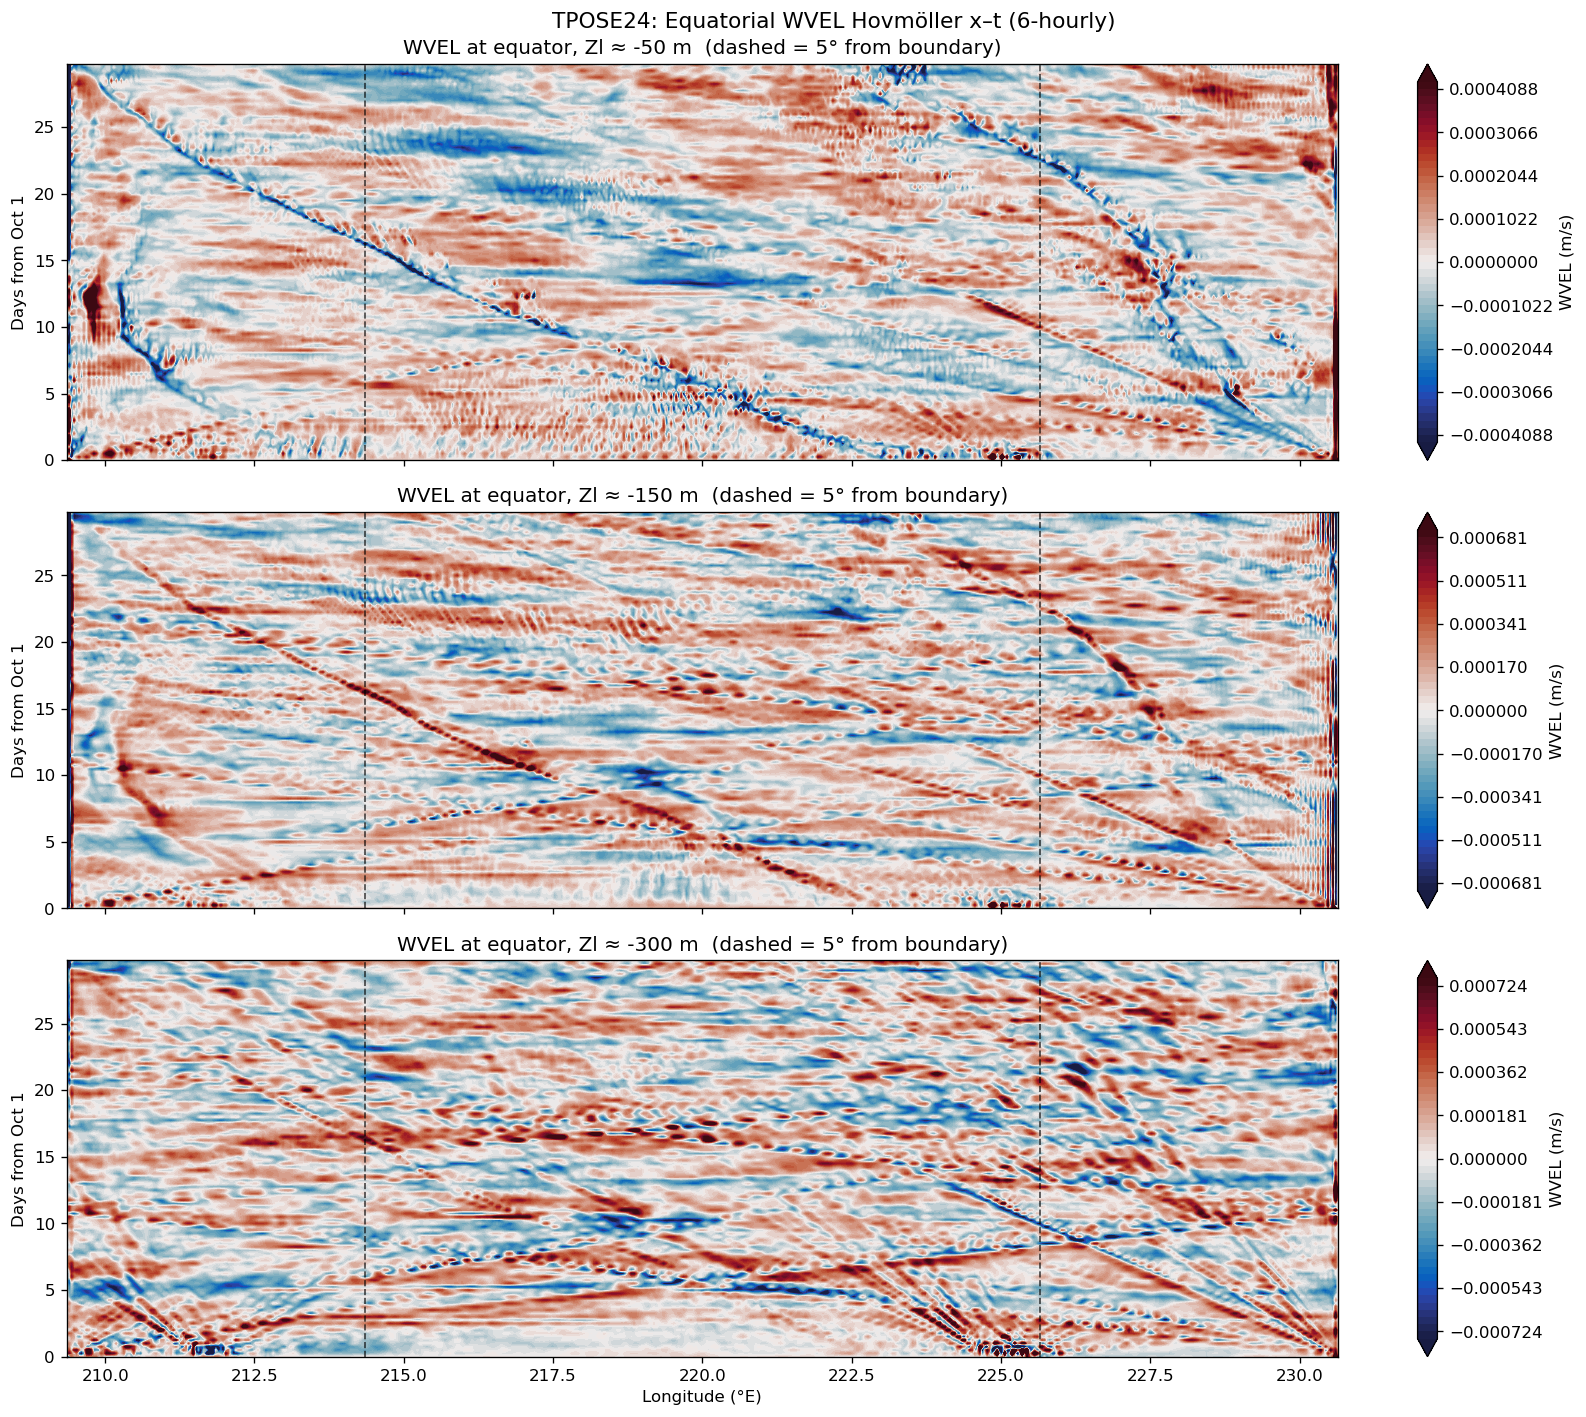

In [4]:
target_depths_zl = [-50., -150., -300.]
t_days_6h = (ds6h.time.values - ds6h.time.values[0]) / np.timedelta64(1, 'D')

fig, axes = plt.subplots(len(target_depths_zl), 1,
                          figsize=(14, 4 * len(target_depths_zl)), sharex=True)

for ax, depth in zip(axes, target_depths_zl):
    w_eq = (ds6h.WVEL
            .sel(Zl=depth, method='nearest')
            .sel(YC=0.0, method='nearest')
            .compute())

    vmax = float(np.nanpercentile(np.abs(w_eq.values), 99))
    cf = cplot(ax, ds6h.XC.values, t_days_6h, w_eq.values,
               cmo.balance, -vmax, vmax)
    plt.colorbar(cf, ax=ax, label='WVEL (m/s)')

    for xv in [int_lon_min, int_lon_max]:
        ax.axvline(xv, color='k', lw=1, ls='--', alpha=0.7)

    zl_actual = float(ds.Zl.sel(Zl=depth, method='nearest'))
    ax.set_ylabel('Days from Oct 1')
    ax.set_title(f'WVEL at equator, Zl ≈ {zl_actual:.0f} m  (dashed = 5° from boundary)')

axes[-1].set_xlabel('Longitude (°E)')
fig.suptitle('TPOSE24: Equatorial WVEL Hovmöller x–t (6-hourly)', fontsize=13)
plt.tight_layout()
plt.savefig('hovmoller_WVEL_eq_xt.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. WVEL depth–time at boundaries vs interior

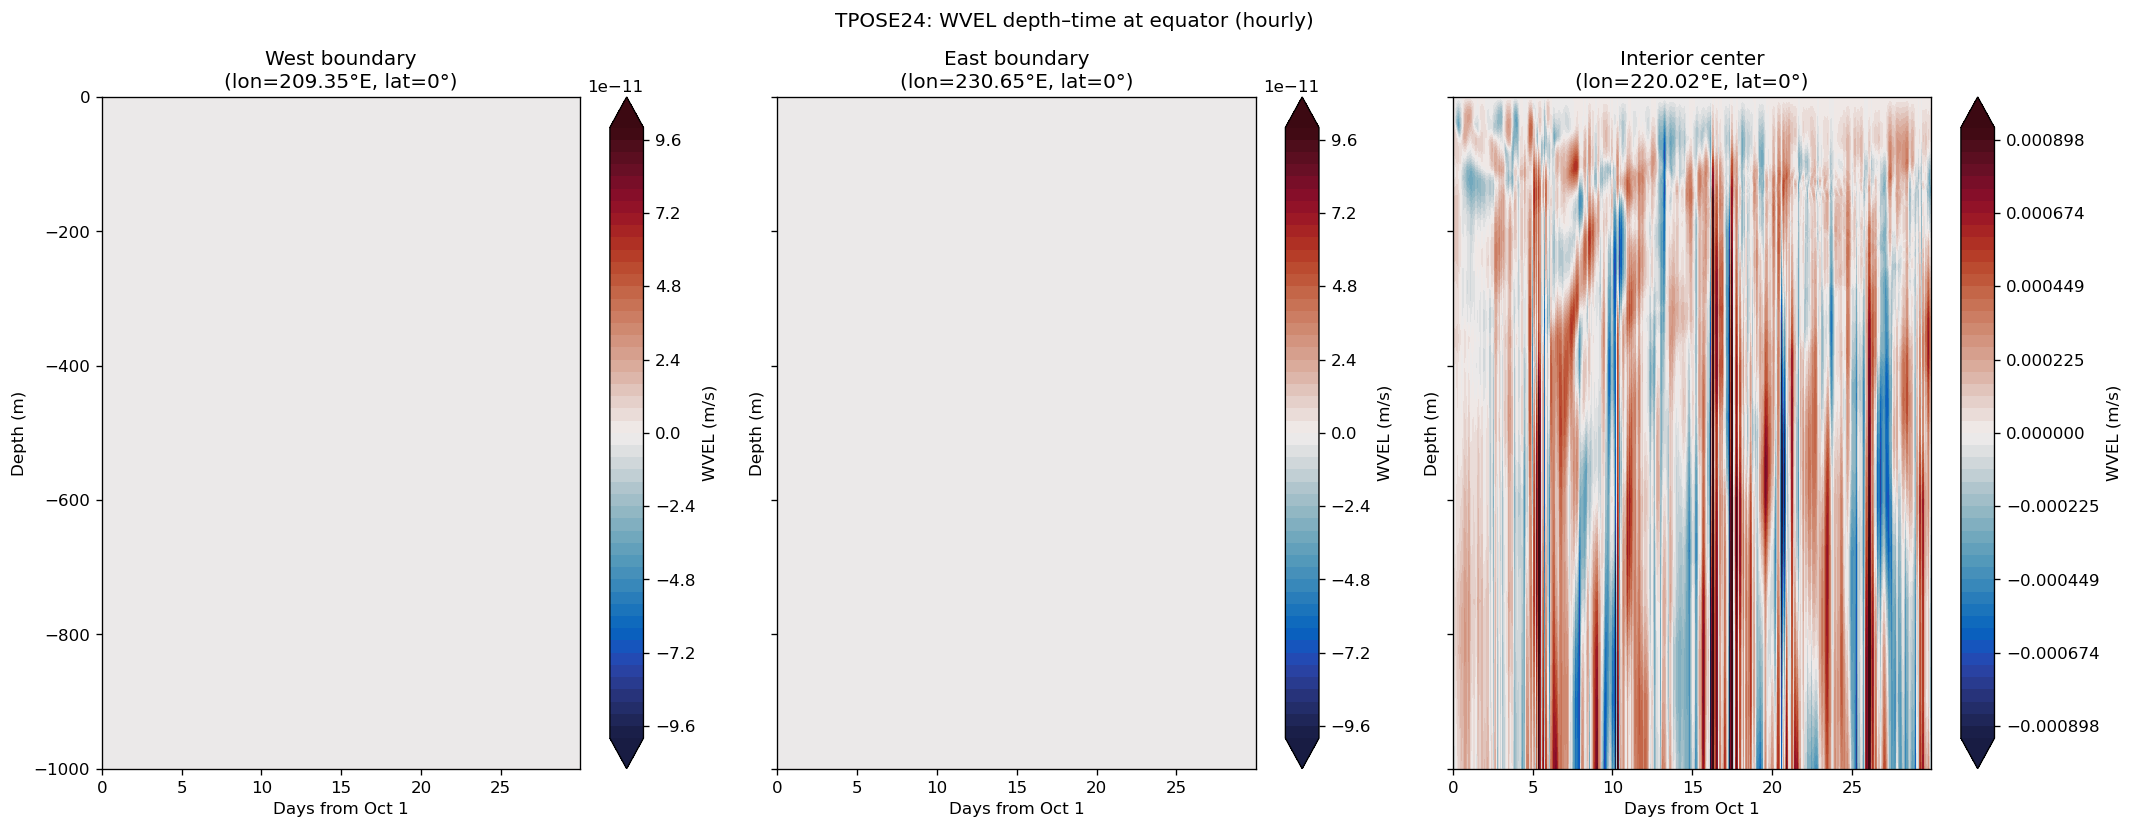

In [5]:
t_days_all = (ds.time.values - ds.time.values[0]) / np.timedelta64(1, 'D')

locations = [
    ('West boundary',   lon_wb_col),
    ('East boundary',   lon_eb_col),
    ('Interior center', lon_int_col),
]

fig, axes = plt.subplots(1, len(locations), figsize=(18, 7), sharey=True)

for ax, (label, lon) in zip(axes, locations):
    w_col = (ds.WVEL
             .sel(XC=lon, method='nearest')
             .sel(YC=0.0, method='nearest')
             .compute())  # (time, Zl)
    vmax = float(np.nanpercentile(np.abs(w_col.values), 99))
    cf = cplot(ax, t_days_all, ds.Zl.values, w_col.values.T,
               cmo.balance, -vmax, vmax)
    plt.colorbar(cf, ax=ax, label='WVEL (m/s)')
    ax.set_xlabel('Days from Oct 1')
    ax.set_ylabel('Depth (m)')
    ax.set_ylim(-1000, 0)
    lon_actual = float(ds.XC.sel(XC=lon, method='nearest'))
    ax.set_title(f'{label}\n(lon={lon_actual:.2f}°E, lat=0°)')

fig.suptitle('TPOSE24: WVEL depth–time at equator (hourly)', fontsize=12)
plt.tight_layout()
plt.savefig('hovmoller_WVEL_zt_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Frequency spectra: boundary vs interior

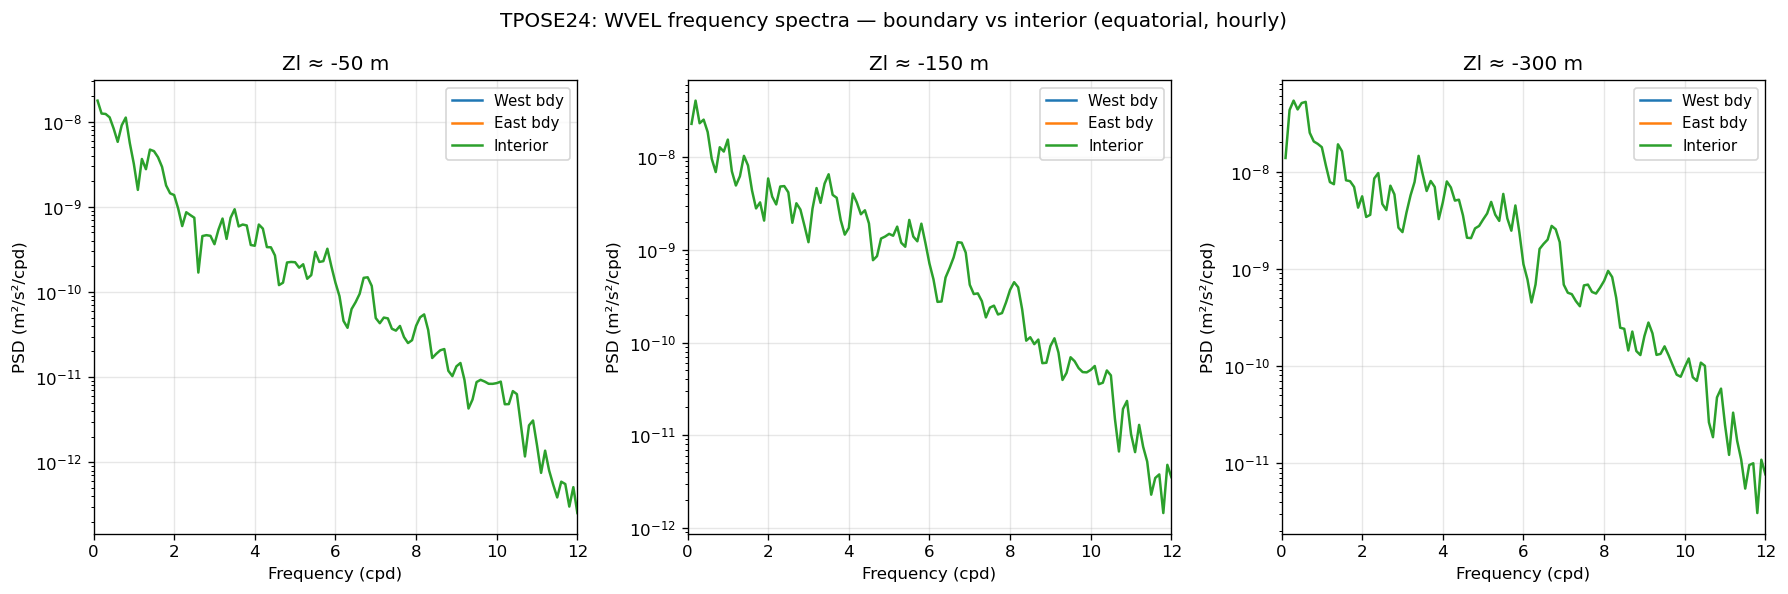

In [6]:
fs_cpd = 24.0
nperseg = min(256, len(ds.time) // 3)

fig, axes = plt.subplots(1, len(target_depths_zl), figsize=(15, 5), sharey=False)

for ax, depth in zip(axes, target_depths_zl):
    zl_actual = float(ds.Zl.sel(Zl=depth, method='nearest'))

    for label, lon, color in [
        ('West bdy',   lon_wb_col,  'C0'),
        ('East bdy',   lon_eb_col,  'C1'),
        ('Interior',   lon_int_col, 'C2'),
    ]:
        ts = (ds.WVEL
              .sel(Zl=depth, method='nearest')
              .sel(XC=lon, method='nearest')
              .sel(YC=0.0, method='nearest')
              .compute().values)
        ts = np.where(np.isnan(ts), 0.0, ts)
        f, Pxx = signal.welch(ts, fs=fs_cpd, nperseg=nperseg)
        ax.semilogy(f[1:], Pxx[1:], label=label, color=color)

    ax.set_xlabel('Frequency (cpd)')
    ax.set_ylabel('PSD (m²/s²/cpd)')
    ax.set_title(f'Zl ≈ {zl_actual:.0f} m')
    ax.legend(fontsize=9)
    ax.set_xlim(0, fs_cpd / 2)
    ax.grid(True, alpha=0.3)

fig.suptitle('TPOSE24: WVEL frequency spectra — boundary vs interior (equatorial, hourly)', fontsize=12)
plt.tight_layout()
plt.savefig('spectra_WVEL_bdy_vs_interior.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. U and V at boundaries

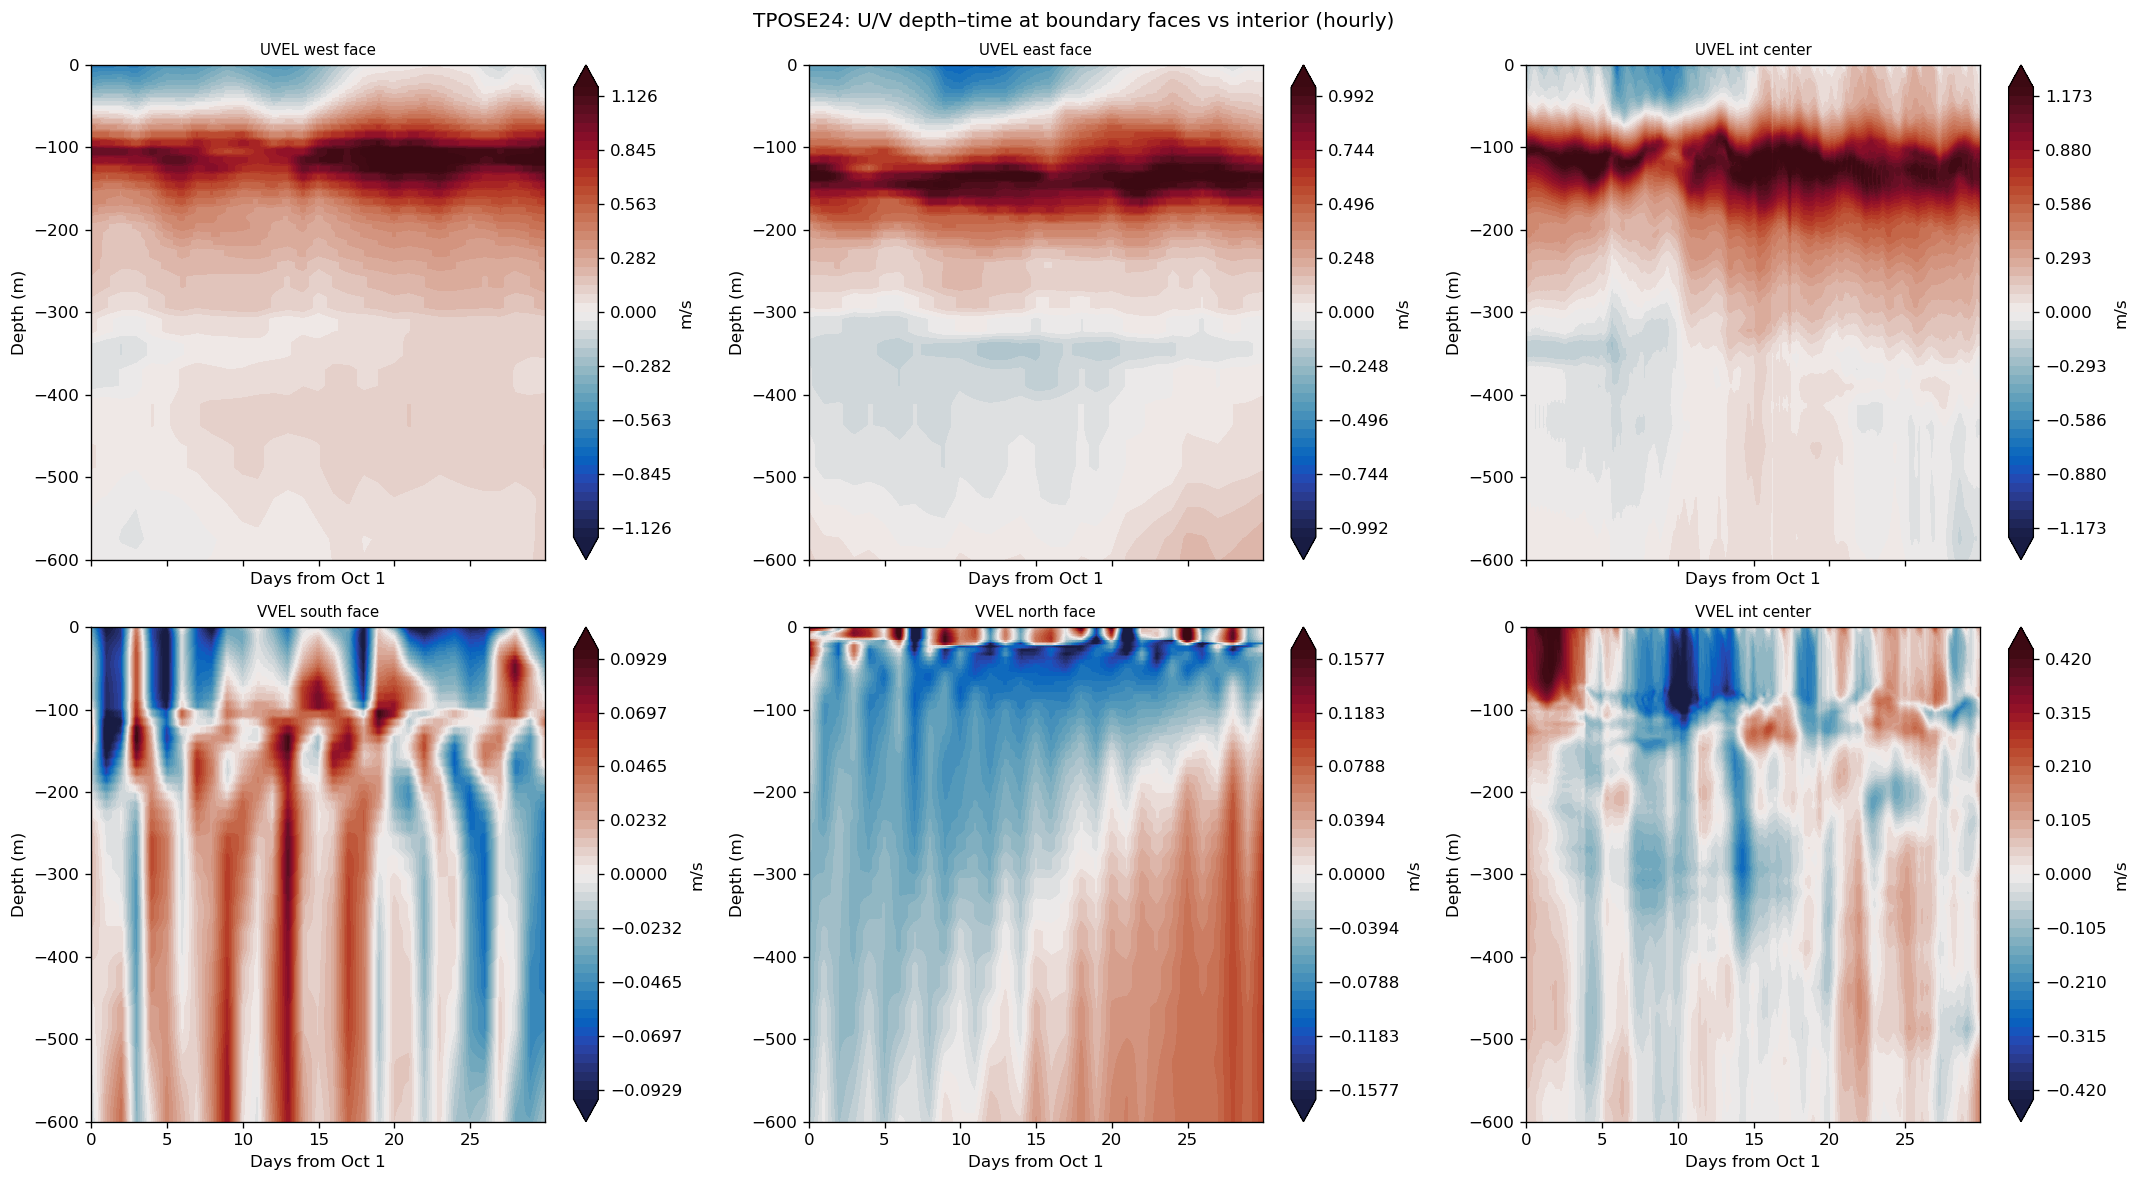

In [7]:
lat_int = (lat_min + lat_max) / 2

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

panels_u = [
    ('UVEL west face',   ds.UVEL.sel(XG=xg_min, method='nearest').sel(YC=0.0, method='nearest')),
    ('UVEL east face',   ds.UVEL.sel(XG=xg_max, method='nearest').sel(YC=0.0, method='nearest')),
    ('UVEL int center',  ds.UVEL.sel(XG=lon_int_col, method='nearest').sel(YC=0.0, method='nearest')),
]
panels_v = [
    ('VVEL south face',  ds.VVEL.sel(YG=yg_min, method='nearest').sel(XC=lon_int_col, method='nearest')),
    ('VVEL north face',  ds.VVEL.sel(YG=yg_max, method='nearest').sel(XC=lon_int_col, method='nearest')),
    ('VVEL int center',  ds.VVEL.sel(YG=lat_int, method='nearest').sel(XC=lon_int_col, method='nearest')),
]

for row_axes, panels in [(axes[0], panels_u), (axes[1], panels_v)]:
    for ax, (title, da) in zip(row_axes, panels):
        arr = da.compute().values  # (time, Z)
        vmax = float(np.nanpercentile(np.abs(arr), 99))
        cf = cplot(ax, t_days_all, ds.Z.values, arr.T,
                   cmo.balance, -vmax, vmax)
        plt.colorbar(cf, ax=ax, label='m/s')
        ax.set_ylim(-600, 0)
        ax.set_title(title, fontsize=9)
        ax.set_ylabel('Depth (m)')
        ax.set_xlabel('Days from Oct 1')

fig.suptitle('TPOSE24: U/V depth–time at boundary faces vs interior (hourly)', fontsize=12)
plt.tight_layout()
plt.savefig('hovmoller_UV_zt_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pressure–velocity energy fluxes at boundaries

Perturbation flux `ρ₀ × PHIHYD′ × vel′` at each open boundary face.

In [8]:
rho0 = 1025.0

def prt_flux(phi_da, vel_da):
    return rho0 * (phi_da - phi_da.mean('time')) * (vel_da - vel_da.mean('time'))

phi_wb = ds.PHIHYD.sel(XC=xg_min, method='nearest')
u_wb   = ds.UVEL.sel(XG=xg_min, method='nearest')
flux_west  = prt_flux(phi_wb, u_wb).mean('YC').compute()

phi_eb = ds.PHIHYD.sel(XC=xg_max, method='nearest')
u_eb   = ds.UVEL.sel(XG=xg_max, method='nearest')
flux_east  = prt_flux(phi_eb, u_eb).mean('YC').compute()

phi_sb = ds.PHIHYD.sel(YC=yg_min, method='nearest')
v_sb   = ds.VVEL.sel(YG=yg_min, method='nearest')
flux_south = prt_flux(phi_sb, v_sb).mean('XC').compute()

phi_nb = ds.PHIHYD.sel(YC=yg_max, method='nearest')
v_nb   = ds.VVEL.sel(YG=yg_max, method='nearest')
flux_north = prt_flux(phi_nb, v_nb).mean('XC').compute()

print('Flux shapes (time, Z):', flux_west.shape)

Flux shapes (time, Z): (720, 138)


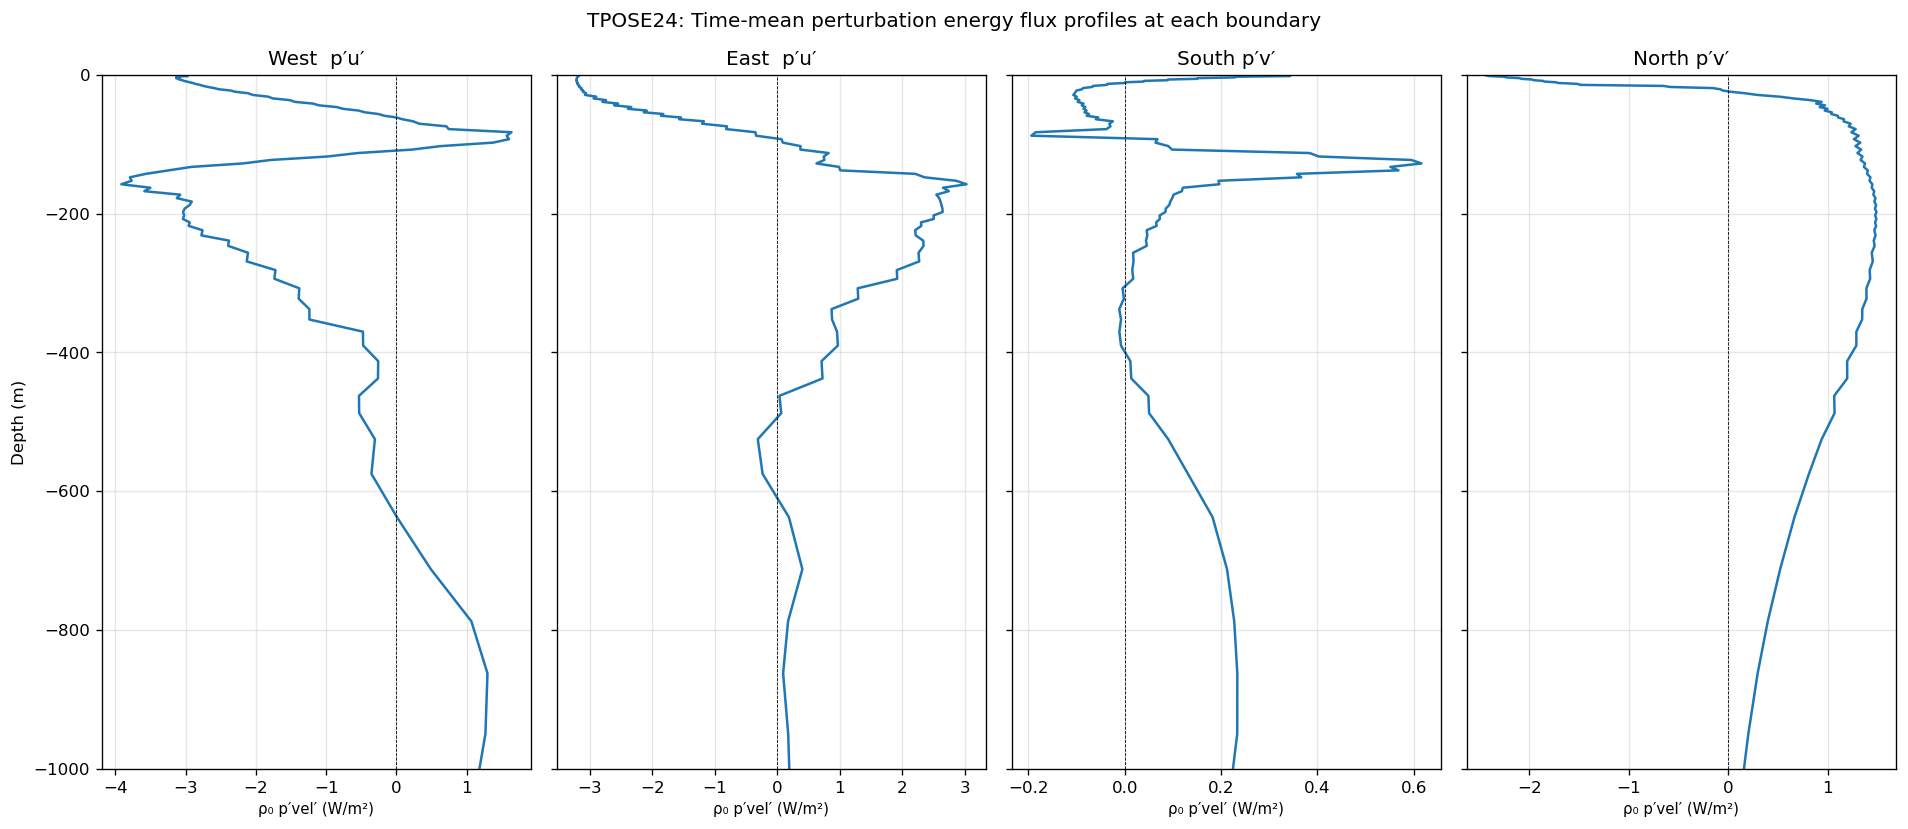

In [9]:
# Time-mean flux profiles
fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)

for ax, label, flux in [
    (axes[0], 'West  p′u′',  flux_west),
    (axes[1], 'East  p′u′',  flux_east),
    (axes[2], 'South p′v′',  flux_south),
    (axes[3], 'North p′v′',  flux_north),
]:
    profile = flux.mean('time')
    ax.plot(profile.values, ds.Z.values, lw=1.5)
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('ρ₀ p′vel′ (W/m²)', fontsize=9)
    ax.set_ylim(-1000, 0)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Depth (m)')
fig.suptitle('TPOSE24: Time-mean perturbation energy flux profiles at each boundary', fontsize=12)
plt.tight_layout()
plt.savefig('energy_flux_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

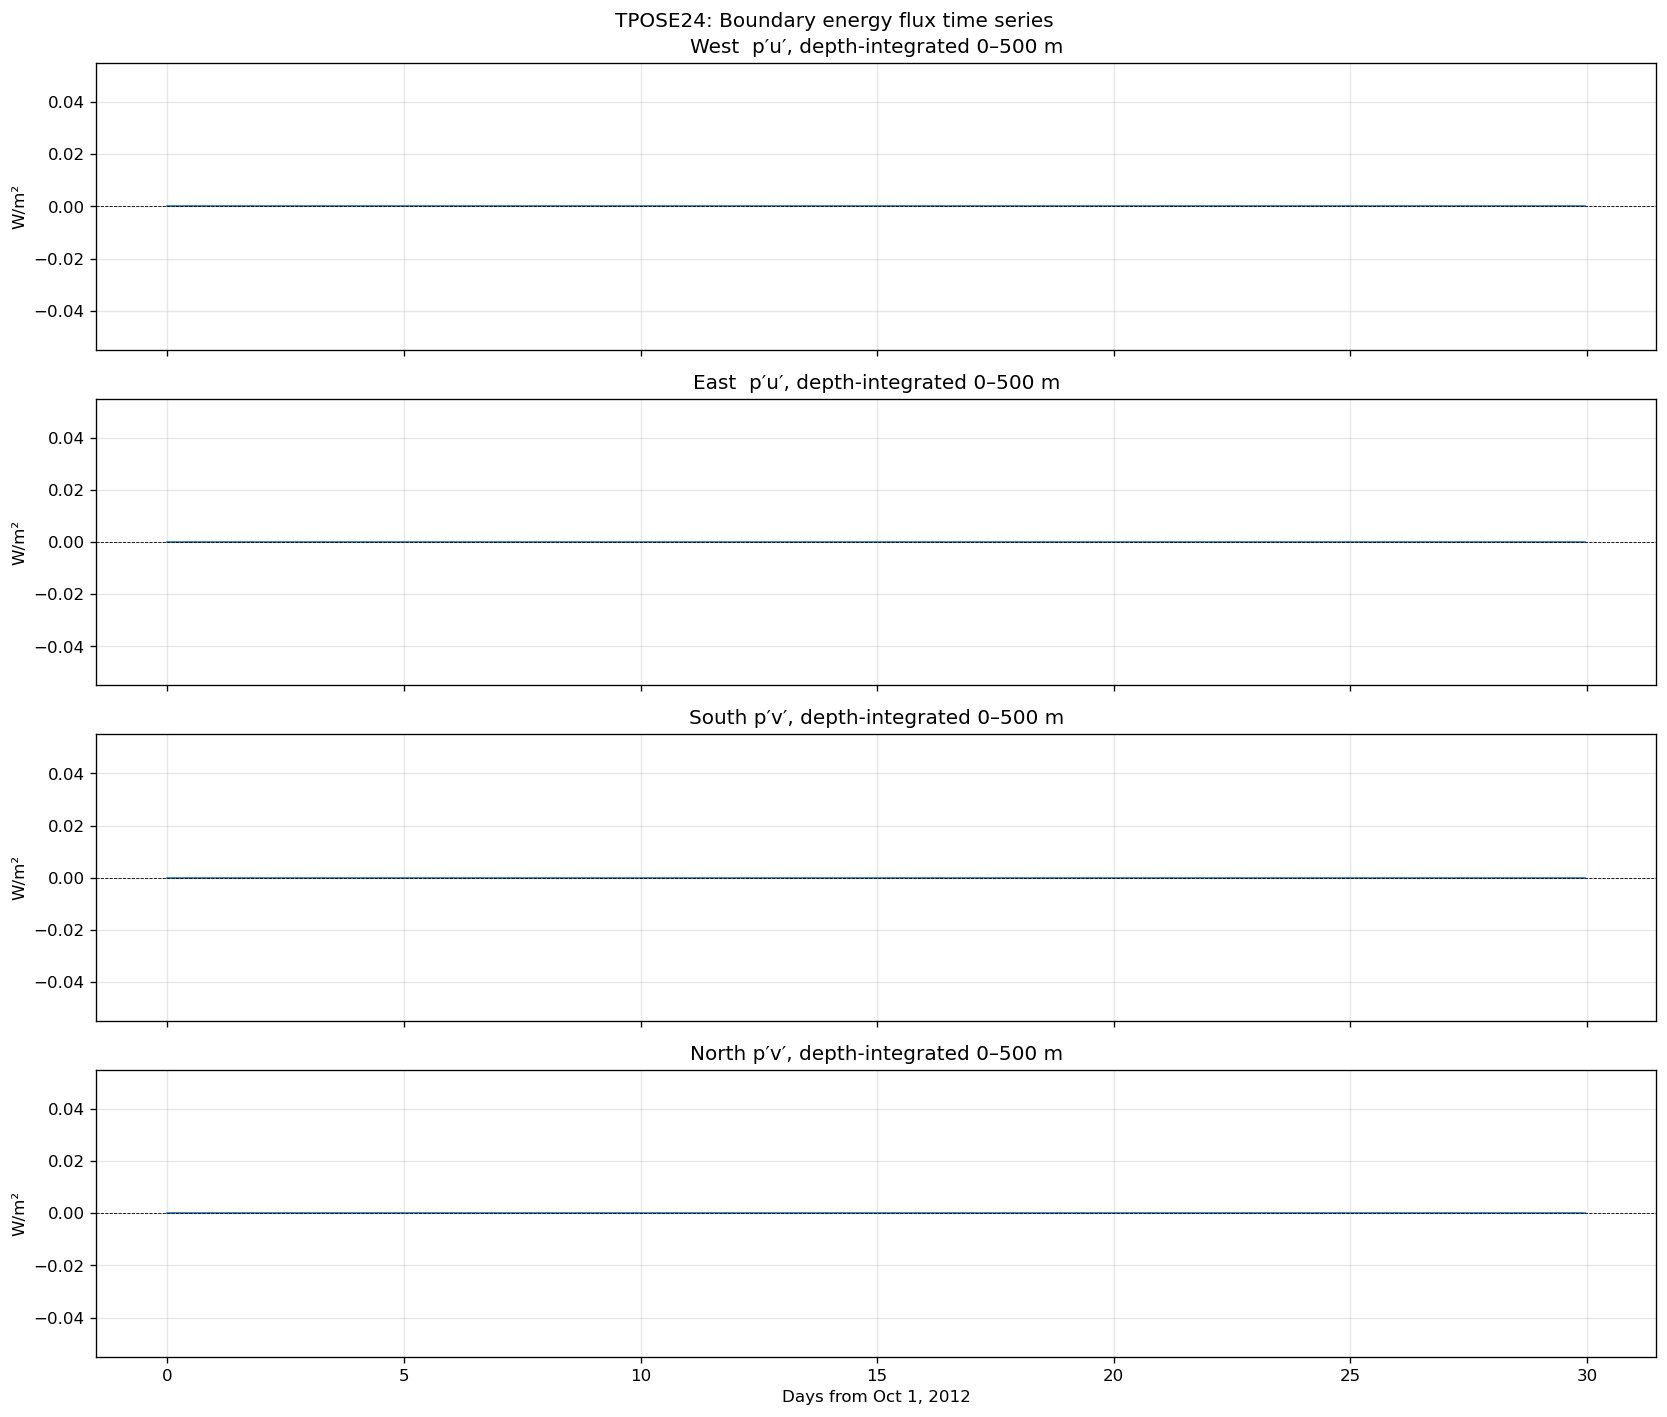

In [10]:
# Depth-integrated flux time series (0–500 m, weighted by drF)
drf = ds.drF.sel(Z=slice(-500, 0))

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, label, flux in [
    (axes[0], 'West  p′u′', flux_west),
    (axes[1], 'East  p′u′', flux_east),
    (axes[2], 'South p′v′', flux_south),
    (axes[3], 'North p′v′', flux_north),
]:
    fi = (flux.sel(Z=slice(-500, 0)) * drf).sum('Z')
    ax.plot(t_days_all, fi.values, lw=1)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel('W/m²')
    ax.set_title(f'{label}, depth-integrated 0–500 m')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Days from Oct 1, 2012')
fig.suptitle('TPOSE24: Boundary energy flux time series', fontsize=12)
plt.tight_layout()
plt.savefig('energy_flux_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. WVEL variance maps

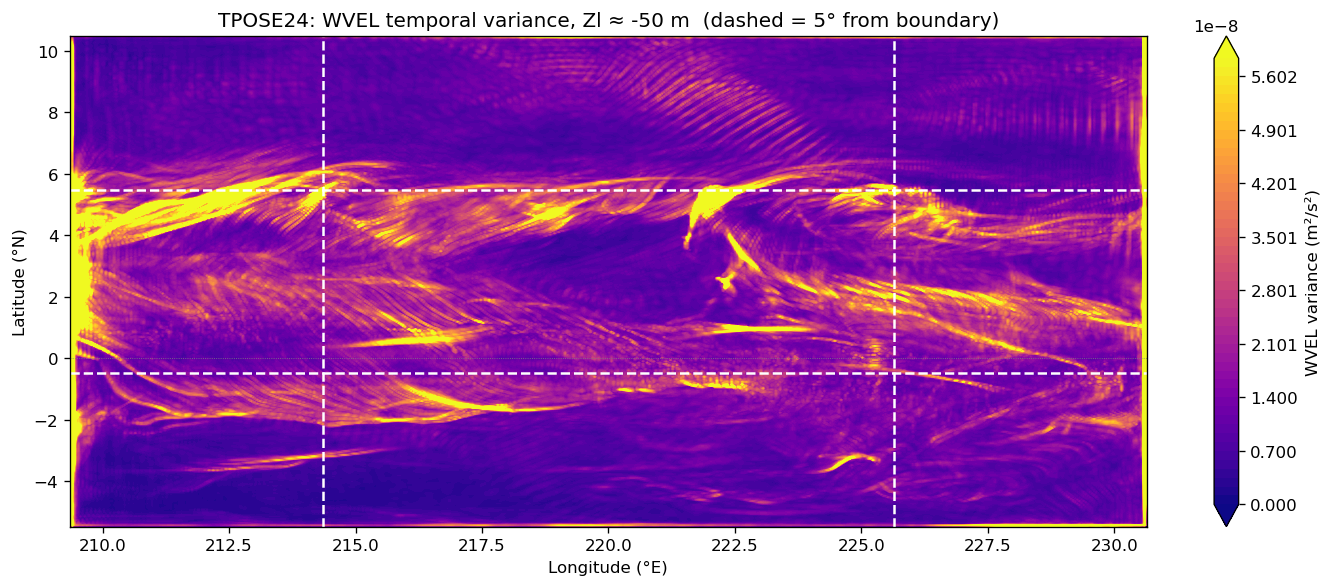

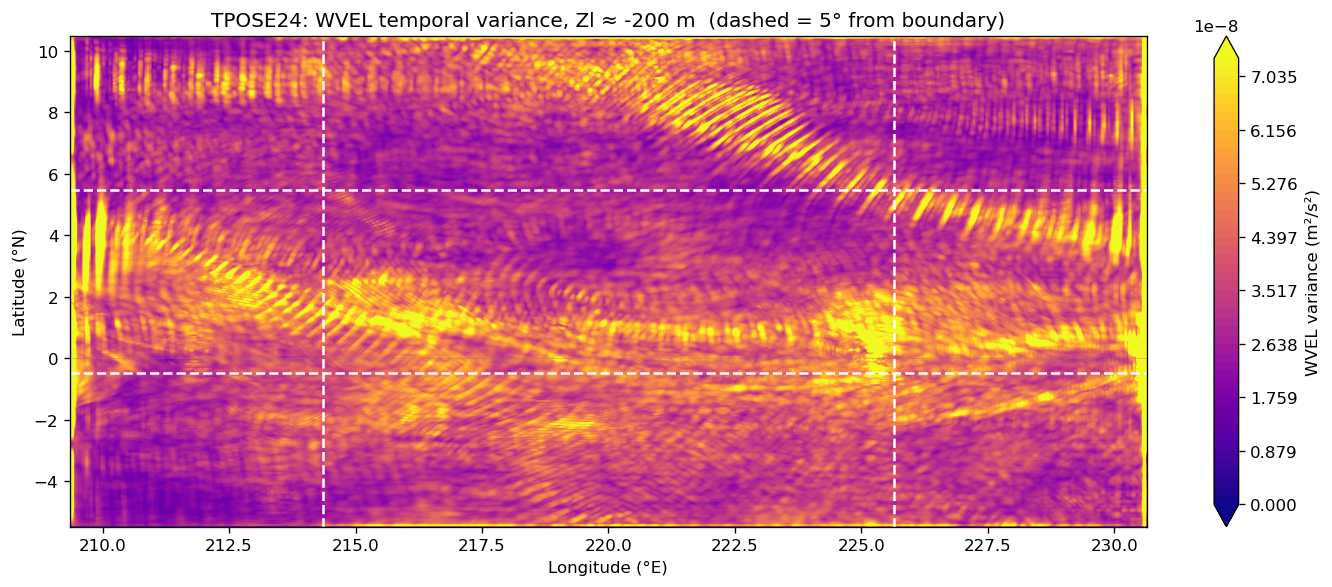

In [11]:
for depth in [-50., -200.]:
    wvar = (ds6h.WVEL
            .sel(Zl=depth, method='nearest')
            .var('time')
            .compute())
    zl_actual = float(ds.Zl.sel(Zl=depth, method='nearest'))

    fig, ax = plt.subplots(figsize=(12, 5))
    vmax = float(np.nanpercentile(wvar.values, 98))
    cf = cplot(ax, ds.XC.values, ds.YC.values, wvar.values,
               'plasma', 0, vmax)
    plt.colorbar(cf, ax=ax, label='WVEL variance (m²/s²)')

    # Mark the 5° buffer boundary (5° from each edge of TPOSE24)
    for xv in [int_lon_min, int_lon_max]:
        ax.axvline(xv, color='w', lw=1.5, ls='--')
    for yv in [int_lat_min, int_lat_max]:
        ax.axhline(yv, color='w', lw=1.5, ls='--')

    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    ax.set_title(f'TPOSE24: WVEL temporal variance, Zl ≈ {zl_actual:.0f} m  (dashed = 5° from boundary)')
    plt.tight_layout()
    plt.savefig(f'WVEL_variance_Zl{abs(int(zl_actual))}m.png', dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
# Variance profile summary: boundary strips vs interior
depth_zl = -50.
wvar_full = (ds6h.WVEL
             .sel(Zl=depth_zl, method='nearest')
             .var('time')
             .compute())

var_wb  = wvar_full.sel(XC=slice(lon_min, lon_min + strip_deg),
                         YC=slice(int_lat_min, int_lat_max)).mean(dim=['XC', 'YC'])
var_eb  = wvar_full.sel(XC=slice(lon_max - strip_deg, lon_max),
                         YC=slice(int_lat_min, int_lat_max)).mean(dim=['XC', 'YC'])
var_int = wvar_full.sel(XC=slice(int_lon_min, int_lon_max),
                         YC=slice(int_lat_min, int_lat_max)).mean(dim=['XC', 'YC'])

print(f'WVEL variance at Zl ≈ {depth_zl} m:')
print(f'  West boundary strip: {float(var_wb):.3e} m²/s²')
print(f'  East boundary strip: {float(var_eb):.3e} m²/s²')
print(f'  Interior:            {float(var_int):.3e} m²/s²')
print(f'  West/Interior ratio: {float(var_wb)/float(var_int):.2f}')
print(f'  East/Interior ratio: {float(var_eb)/float(var_int):.2f}')

WVEL variance at Zl ≈ -50.0 m:
  West boundary strip: 2.345e-07 m²/s²
  East boundary strip: 7.020e-08 m²/s²
  Interior:            1.986e-08 m²/s²
  West/Interior ratio: 11.81
  East/Interior ratio: 3.53
